# RNN Layer


## Basic RNN Architecture

We prefer the Recurrent Neural Network (RNN) in the scenarios where the current state of the input has a dependency on the previous state of the input and so on so forth. For example, if we're to forecast the temperature of today's weather then we're going to decide the results based on historical data. Similarly, forecasting future gold price, predicting the next word while we're writing an e-mail, etc. have dependencies on past data.

We can, of course, go with multi-layer perceptron or convolutional neural network approaches but the former will create an overhead of weights by creating too many unnecessary connections and the latter is more suitable for image data. Therefore, a need for a new network is raised which can work on applications which are solely based upon historical data. The RNN is the building block for the forecasting on such sequence data.

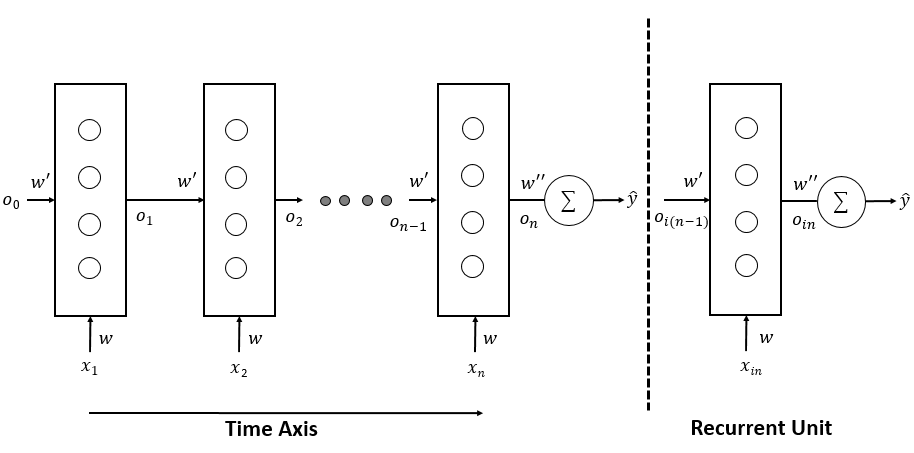

This is a basic architecture of an **RNN**. To understand it, take a look at the **L.H.S.** diagram of the dashed line. Assuming we have a time series data with **N** values gathered over **N** days. We start by feeding the first value (**x<sub>1</sub>**) from the input layer to the hidden layer having **r** number of nodes. The weights connecting the input layer and the hidden layer is **w**. When we perform the dot product and have the final output (**o<sub>1</sub>**) ready, we feed the new input **x<sub>2</sub>** along with the previous output o1 in the same hidden layer. Do note that only time changes when second input is feed, but hidden layer and weights **w** and **w'** remains the same. This process keeps repeating unless we arrive at the final **N<sup>th</sup>** data value. Once we do, then we can apply a final activation function to get the forecasted value **y** (hat).

If we observe the diagram, the architecture follows a repeating pattern of fetching an input value (**x<sub>t</sub>**) and previous output (**o<sub>t-1</sub>**) and resulting in a new output (**o<sub>t</sub>**). Therefore, if we can just add a random initialized output (**o<sub>0</sub>**) before the process begin then the whole network can be represented as a recurrent unit as shown in the **R.H.S.** of the dashed line.

If we assume that the hidden layer employs an activation function **F** and final activation function is **G**, then the forward propagation of given architecture can be inferred from the given equations:

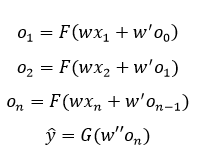

Notice that in each step, the output is dependent upon the current input and last output. For instance, **o<sub>2</sub>** is dependent upon **x<sub>2</sub>** and **o<sub>1</sub>**. This time, backpropagation happens over time on the same hidden layer and for n times steps, we will get **n** gradients for **w** as well as **w'**. Later on, we accumulate those gradients and update **w** and **w'** for the next review.

Now, the problem is, if the sequence is large enough, then while computing the backpropagation to arrive at the first value, either the gradient becomes too small or it becomes too large for the optimization algorithm to converge. 

To recover the algorithm from the exploding gradient, we can either deploy penalty or follow variants of backpropagation over time like **truncated BPTT**. To recover from the vanishing gradient we can improve the weight initialization or follow more robust **RNN variants** like **LSTM** and **GRU**.

## RNN Architecture Variants

### One to One

This is the architecture which we have seen previously where we have one input and corresponding one output as shown in the block architecture.

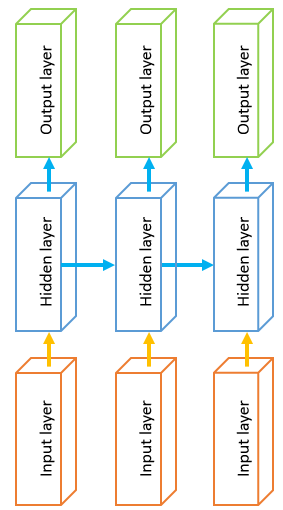

### One to Many

In this architecture, we provide input and expect multiple outputs. Generally, such architecture is seen in the process of image captioning where we provide an input image and expect multiple words (output) corresponding to the image.

Example -

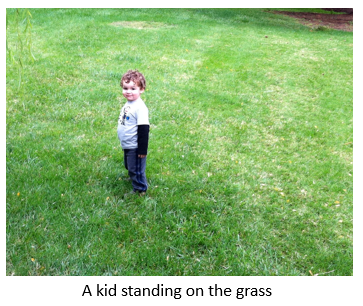

The corresponding block architecture of one to many can be represented as follows:

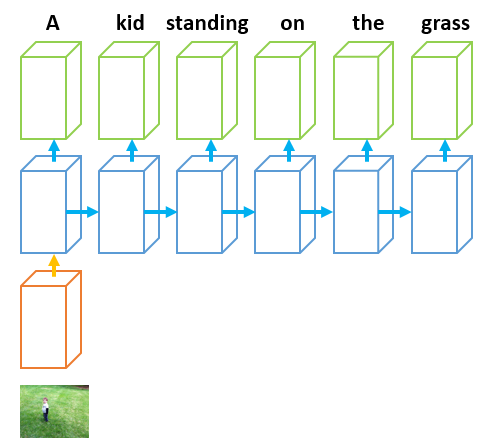

### Many to One

In this architecture, there are multiple inputs mapped to a single output. Consider a case of finding a sentence sentiment (positive/neutral/negative). So, we pass various words (inputs) which need to arrive at a single output (sentiment of the sentence).

For example:

**Positive sentiment:** The food in this restaurant is very delicious.

**Negative sentiment:** It is sad to hear the recent earthquake news.

**Neutral sentiment:** Yes!

Here's the block architecture of the same:

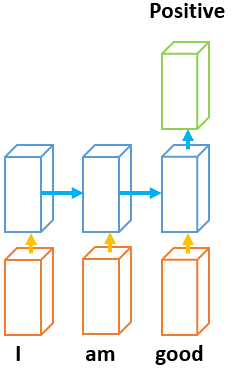

### Many to Many

Here, we provide multiple inputs and expect multiple outputs from the network. Consider machine translation where we convert a sentence from language A to language B. So, both input and output have multiple entries. The block diagram for the same is given below:

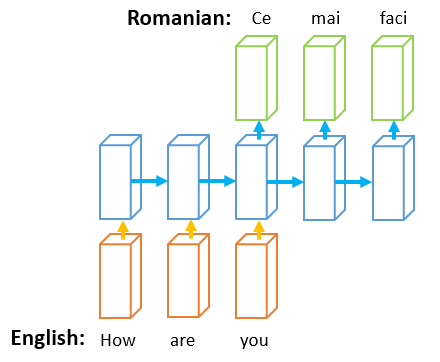

## RNN Variants

### Long Short-Term Memory (LSTM)

Recall from the previous basic **RNN structure** where, at a given timestamp we have only two inputs (**x<sub>n</sub>** and **o<sub>n-1</sub>**) resulting only in one output (**o<sub>n</sub>**).

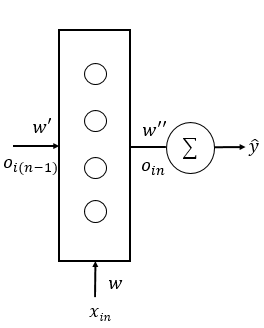

As we know that such structures have problems with gradients which can either vanish or explode. To recover from such a situation, researchers presented a new variant to RNN named as **Long Short-Term Memory** which has an ability to preserve the effects of old inputs in a long sequence as well as keep the effects of new inputs too. To understand this process visually, observe the given figure:

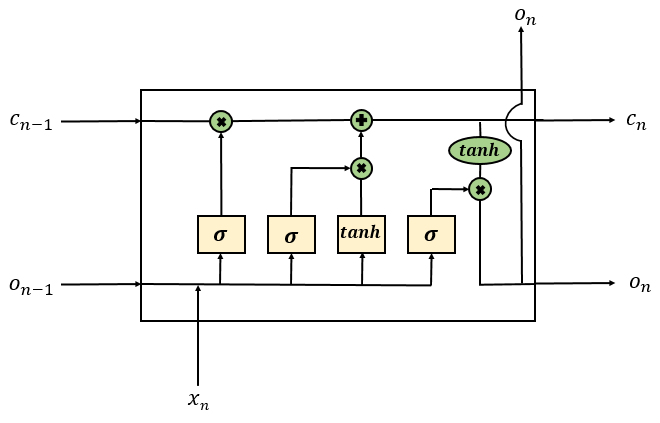

This is an **LSTM cell** where the yellow units represent the network layer, green units represent the pointwise operation (either multiplication or addition), 2 arrow lines meeting together represent the concatenation and an arrow line splitting represents copying the values.

As you can observe at a given timestamp, you got 3 inputs along with 2 outputs rather than usual 2 inputs and 1 output when compared with basic RNN structure. The above LSTM unit is divided into 3 separate parts: **Forget gate, Input gate, and Output gate**. Let us discuss the usage of each one of them to cover the functioning of whole LSTM cell.

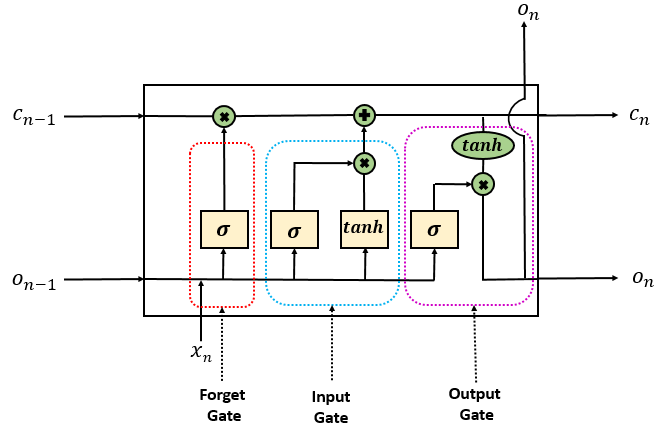

#### Forget Gate

The forget gate (highlighted in the red box) consists of a **sigmoid activation layer** which helps in taking control of how much previous data needs to be retained and how much of it needs to be expelled. A definite 1 represents keep all the data whereas a definite 0 represents exclude all the data.

Observe that we are not doing any dot product between **x<sub>n</sub>** and **y (hat) <sub>n-1</sub>** anywhere. Rather we are performing the concatenation or merging operation. The governed equation of the resulting function can be written as:

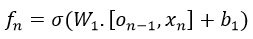

Where **W<sub>1</sub>** represents the combined **weights** and **b<sub>1<sub>** represents **bias**. Note, we have used **,** in the equation which represents **concatenation**. The output **f<sub>t</sub>** proceeds with the **pointwise multiplication operator** as seen in the diagram to control the amount of information to be sent ahead.

#### Input Gate

The input gate (highlighted in the blue box) helps to add new information to the final output **o<sub>n</sub>** by the pointwise multiplication of the following 2 terms:

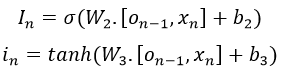

Giving us the final output as the pointwise addition of the forget gate output and the input gate output as shown:

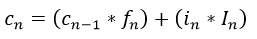

#### Output Gate

Finally, to produce the forecasted output **y<sub>t</sub>**, we need the pointwise multiplication of the following 2 terms inside the output gate (highlighted in the pink box):

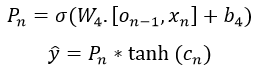

### Forecasting stocks using LSTM ( Single Variable Time Series Forcasting)

#### Installing packages

In [ ]:
%pip install numpy pandas matplotlib keras scikit-learn tensorflow

#### Importing libraries

In [ ]:
import numpy as np # for numerical operations
import pandas as pd # for data manipulation
import matplotlib.pyplot as plt # for plotting graphs
import keras # for building neural networks
from keras.models import Sequential # for creating a sequential model
from keras.layers.recurrent import LSTM # for LSTM layers
from keras.layers.core import Dense, Activation, Dropout # for dense layers, activation functions, and dropout
from sklearn.preprocessing import MinMaxScaler # for scaling data
from sklearn.metrics import mean_squared_error # for evaluating the model
import tensorflow as tf # for deep learning functionalities

#### Loading data

In [ ]:
data = pd.read_csv('INFY_2000_2008.csv')
data.info()

#### Selecting only Date and Average Price columns

In [ ]:
data = data[['Date', 'Average Price']]

#### Scaling & splitting

In [ ]:
# Scaling the values in the range of 0 to 1
scaler = MinMaxScaler(feature_range = (0, 1))
scaled_price = scaler.fit_transform(data.loc[:, 'Average Price'].values.reshape(-1, 1))
# Splitting dataset in the ratio of 75:25 for training and test
train_size = int(data.shape[0] * 0.75)
train, test = scaled_price[0:train_size, :], scaled_price[train_size:data.shape[0], :]
print("Number of entries (training set, test set): " + str((len(train), len(test))))

#### Method to create new dataset

Next, we need to construct a data set from the array of Average Price values along with defining a window size. Window is used to define how many values need to be taken while forecasting the new value. By default, in the function, we set the window size as 1, however, while constructing the data set, we set the window size to 3. You can change it and observe the corresponding effect on the forecasted value.

In [ ]:
def create_dataset(scaled_price, window_size=1):
    data_X, data_Y = [], []
    for i in range(len(scaled_price) - window_size - 1):
        a = scaled_price[i:(i + window_size), 0]
        data_X.append(a)
        data_Y.append(scaled_price[i + window_size, 0])
    return(np.array(data_X), np.array(data_Y))


#### Calling the function and reset the dataset to make it fit for Keras

In [ ]:
# Create test and training sets for one-step-ahead regression.
window_size = 3
train_X, train_Y = create_dataset(train, window_size)
test_X, test_Y = create_dataset(test, window_size)
print("Original training data shape:")
print(train_X.shape)
# Reshape the input data into appropriate form for Keras.
train_X = np.reshape(train_X, (train_X.shape[0], 1, train_X.shape[1]))
test_X = np.reshape(test_X, (test_X.shape[0], 1, test_X.shape[1]))
print("New training data shape:")
print(train_X.shape)


#### Creation of LSTM Netork

with 4 blocks & 1 layer using MSE as loss function with 3 epochs

In [ ]:
# Designing the LSTM model
model = Sequential()
model.add(LSTM(4, input_shape = (1, window_size)))
model.add(Dense(1))
# Compiling the model
model.compile(loss = "mean_squared_error", optimizer = "adam")
# Training the model
model.fit(train_X, train_Y, epochs=3, batch_size=1)

#### Forecasting and visualization

Let us now check the MSE in train and test data and perform the corresponding visualization:

In [ ]:
def predict_and_score(model, X, Y):
    # Make predictions on the original scale of the data.
    pred = scaler.inverse_transform(model.predict(X))
    # Prepare Y data to also be on the original scale for interpretability.
    orig_data = scaler.inverse_transform([Y])
    # Calculate RMSE.
    score = np.sqrt(mean_squared_error(orig_data[0], pred[:, 0]))
    return(score, pred)
rmse_train, train_predict = predict_and_score(model, train_X, train_Y)
rmse_test, test_predict = predict_and_score(model, test_X, test_Y)
print("Training data score: %.2f RMSE" % rmse_train)
print("Test data score: %.2f RMSE" % rmse_test)

In [ ]:
# Initiating with training predictions.
train_predict_plot = np.empty_like(scaled_price)
train_predict_plot[:, :] = np.nan
train_predict_plot[window_size:len(train_predict) + window_size, :] = train_predict
# Adding test predictions.
test_predict_plot = np.empty_like(scaled_price)
test_predict_plot[:, :] = np.nan
test_predict_plot[len(train_predict) + (window_size * 2) + 1:len(scaled_price) - 1, :] = test_predict
# Creating the plot.
plt.figure(figsize = (15, 5))
plt.plot(scaler.inverse_transform(scaled_price), label = "True value")
plt.plot(train_predict_plot, label = "Training set prediction")
plt.plot(test_predict_plot, label = "Test set prediction")
plt.xlabel("Days")
plt.ylabel("Average Price")
plt.title("Comparison true vs. predicted training / test")
plt.legend()
plt.show()

### Forecasting stocks using LSTM ( Multivariate Time Series Forcasting)
To perform the multivariate time series forecast using 3 inputs: **Last Price, Average Price, and Open Price**

#### Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras.models import Sequential
from keras.layers.recurrent import LSTM
from keras.layers.core import Dense, Activation, Dropout
from sklearn.preprocessing import MinMaxScaler

#### Forecasting Visualisation

In [ ]:
# Loading data
data = pd.read_csv('/workspaces/AIML_BigProjects/Forecasting Stocks/INFY20002008.csv')
# Selecting three columns as input 
data = data[['Last Price', 'Average Price', 'Open Price']].values
plt.figure(figsize=(10, 6))
plt.plot(data[:,0]+500, '--g', label='Last Price')
plt.plot(data[:,1], '--r', label='Average Price')
plt.plot(data[:,2]-500, '--b', label='Open Price')
plt.xlabel('Days', fontsize=15)
plt.ylabel('Price', fontsize=15)
plt.suptitle('Plot of Last, Average and Open price', fontsize=18, weight='bold')
plt.title('with added noise to prevent overlapping')
plt.legend()
plt.show()

You are required to split the dataset in the ratio of 75:25 and train an LSTM model with four units, single LSTM layer till three epochs. 

#### Scaling & Splitting

In [ ]:
# Scaling the values in the range of 0 to 1
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data[:,:])

# Splitting dataset in the ratio of 75:25 for training and test
train_size = int(scaled_data.shape[0] * 0.75)
train, test = scaled_data[0:train_size, :], scaled_data[train_size:scaled_data.shape[0], :]
print("Number of entries (training set, test set): " + str((len(train), len(test))))

#### Function to create new dataset

In [ ]:
def create_dataset(ser, window_size=1):
    data_X, data_Y = [], []
    for i in range(len(ser) - window_size - 1):
        a = []
        for j in range(0, window_size):        
            a.append(ser[[(i+j)], :])
        data_X.append(a)
        data_Y.append(ser[i + window_size, 1])
    return(np.array(data_X), np.array(data_Y))

#### Reshaping

In [ ]:
window_size = 50
train_X, train_Y = create_dataset(train, window_size)
test_X, test_Y = create_dataset(test, window_size)
print("Original training data shape:")
print(train_X.shape, test_X.shape)

# Reshape the input data into appropriate form for Keras.
train_X = np.reshape(train_X, (train_X.shape[0], train_X.shape[1], 3))
test_X = np.reshape(test_X, (test_X.shape[0], test_X.shape[1], 3))
print("New training data shape:")
print(train_X.shape, test_X.shape)

#### Design, Compile, Train

In [ ]:
# Designing the LSTM model
model = Sequential()
model.add(LSTM(4, input_shape = (window_size, 3)))
model.add(Dense(1))

# Compiling the model
model.compile(loss = "mean_squared_error", optimizer = "adam")

# Training the model
model.fit(train_X, train_Y, epochs=3, batch_size=1)

#### Visualization

Here's the visualized output w.r.t. the Average Price.

In [ ]:
# Visualization
plt.figure(figsize = (15, 5))
plt.plot(np.concatenate((train[:,1], test[:,1])), '--b', label='True value')

plt.plot(range(window_size, len(train_X) + window_size), model.predict(train_X), '-r', label='Training set prediction')
plt.plot(range(window_size + len(train), len(train) + len(test) - 1), model.predict(test_X), '-g', label='Test set prediction')

plt.xlabel("Days")
plt.ylabel("Average Price")
plt.title("Comparison true vs. predicted training / test", fontsize=16)
plt.legend()
plt.xlim(-5, 2500)
plt.show()

### Gated Recurrent Unit (GRU)

Gated Recurrent Unit (GRU) which has only 2 gates, **reset gate and update gate (a combination of the forget and input gates)**. This helps in increasing the performance by reducing the number of gradients to be computed.

### Bidirectional RNN (BRNN).


